# SFT Human Evaluation Results
This notebook provides a visual and interactive interface to the evaluation metrics. It relies on the refactored `src` package.

In [15]:
import warnings
warnings.filterwarnings("ignore")

from src.config import PRINT_LABELS, TASKS
from src.metrics import (
    aggregate_emotion_hits, compute_emotion_hits, compute_iaa_alpha,
    compute_mean_std, compute_overall_quality, compute_rank_at_k,
    iaa_uids_for
)
from src.plots import plot_hits_by_emotion, plot_hits_by_model
from src.results_loader import load_all_annotators

In [16]:
results = load_all_annotators()
print(f"Loaded {len(results)} annotators: {[r.annotator.name for r in results]}")

Loaded 4 annotators: ['anno1', 'anno2', 'anno3', 'anno4']


## 1. Rank@K and Mean/Std (Per Annotator)

In [17]:
for res in results:
    for k in (1, 2):
        print(compute_rank_at_k(res, k=k).render())
        print()
    print(compute_mean_std(res).render())
    print("-" * 50 + "\n")

print(compute_overall_quality(results).render())

ANNO 1 @1 - Task 1 - Task 3
GLM4     - 0.381  - 0.238
Gemma2   - 0.190  - 0.333
LLaMA3   - 0.190  - 0.143
Mistral  - 0.048  - 0.095
Phi3     - 0.190  - 0.143

ANNO 1 @2 - Task 1 - Task 3
GLM4     - 0.476  - 0.333
Gemma2   - 0.429  - 0.381
LLaMA3   - 0.286  - 0.571
Mistral  - 0.429  - 0.381
Phi3     - 0.381  - 0.238

ANNO 1       -- Task 1 -- Task 3 -- Task 4

GLM4 MEAN   -- 2.762  -- 3.190  -- 3.190
GLM4 STD    -- 1.670  -- 1.601  -- 0.602

Gemma2 MEAN   -- 2.952  -- 2.571  -- 2.952
Gemma2 STD    -- 1.431  -- 1.248  -- 0.805

LLaMA3 MEAN   -- 2.857  -- 2.762  -- 2.952
LLaMA3 STD    -- 1.153  -- 1.338  -- 0.498

Mistral MEAN   -- 3.000  -- 3.048  -- 3.000
Mistral STD    -- 1.140  -- 1.284  -- 0.632

Phi3 MEAN   -- 3.429  -- 3.333  -- 3.333
Phi3 STD    -- 1.660  -- 1.354  -- 0.658
--------------------------------------------------

ANNO 2 @1 - Task 1 - Task 3
GLM4     - 0.381  - 0.333
Gemma2   - 0.048  - 0.095
LLaMA3   - 0.286  - 0.143
Mistral  - 0.095  - 0.190
Phi3     - 0.190  - 0.238


## 2. Task 2: Emotion Hit Counts

In [18]:
all_hits = [compute_emotion_hits(res) for res in results]
overall = aggregate_emotion_hits(all_hits)

per = max((len(r.tasks[2]) for r in results), default=45)

for hits in all_hits:
    print(f"{hits.annotator_name}  - Task 2")
    for label, n in zip(PRINT_LABELS, hits.total_hit_counts()):
        print(f"{label:<8} - {n} / {per}")
    print()

print("OVERALL Task 2 - mean model hits")
for label, n in zip(PRINT_LABELS, overall.means):
    print(f"{label:<8} - {n:g} / {per}")
print(overall.per_emotion)

ANNO 1  - Task 2
HUMAN    - 22 / 45
GLM4     - 18 / 45
GEMMA2   - 15 / 45
LLAMA3   - 17 / 45
MISTRAL  - 16 / 45
PHI3     - 21 / 45

ANNO 2  - Task 2
HUMAN    - 24 / 45
GLM4     - 19 / 45
GEMMA2   - 24 / 45
LLAMA3   - 28 / 45
MISTRAL  - 21 / 45
PHI3     - 22 / 45

ANNO 3  - Task 2
HUMAN    - 20 / 45
GLM4     - 26 / 45
GEMMA2   - 23 / 45
LLAMA3   - 24 / 45
MISTRAL  - 25 / 45
PHI3     - 28 / 45

ANNO 4  - Task 2
HUMAN    - 28 / 45
GLM4     - 29 / 45
GEMMA2   - 26 / 45
LLAMA3   - 27 / 45
MISTRAL  - 25 / 45
PHI3     - 30 / 45

OVERALL Task 2 - mean model hits
HUMAN    - 23.5 / 45
GLM4     - 23 / 45
GEMMA2   - 22 / 45
LLAMA3   - 24 / 45
MISTRAL  - 21.75 / 45
PHI3     - 25.25 / 45
Counter({'Neutral': 106, 'Happiness': 96, 'Surprise': 91, 'Fear': 78, 'Sadness': 75, 'Anger': 58, 'Disgust': 54})


### Visualizations

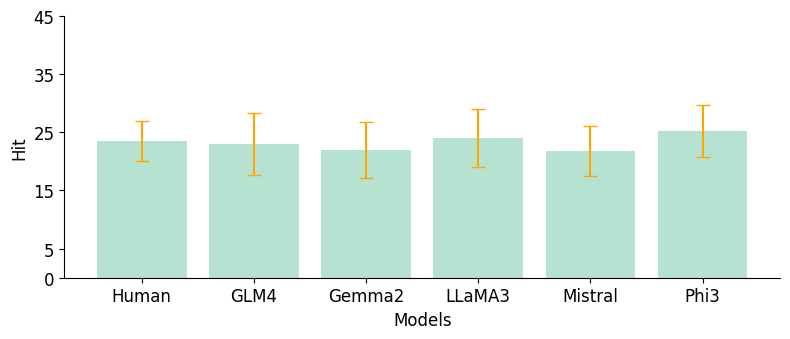

In [19]:
plot_hits_by_model(
    overall.means, stds=overall.stds,
    ylim=per or 45, title=""
)

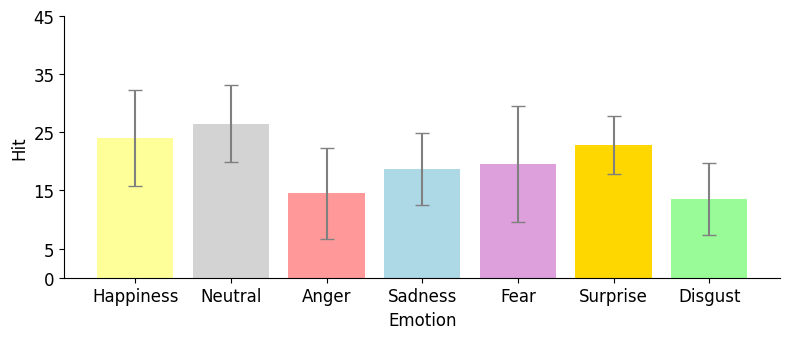

In [20]:
plot_hits_by_emotion(
    overall.per_emotion_mean,
    stds_by_emotion=overall.per_emotion_std,
    ylim=per or 45, title=""
)

## 3. Inter-Annotator Agreement (Krippendorff Alpha)

In [21]:
iaa_uids_by_task = {
    t.num: iaa_uids_for(t.num, ["SFTANNO-000006", "SFTANNO-000011", "SFTANNO-000018", "SFTANNO-000019", "SFTANNO-000025", "SFTANNO-000031", "SFTANNO-000066"]) 
    for t in TASKS
}
alpha_by_task = compute_iaa_alpha(results, iaa_uids_by_task)

print("IAA")
for num, value in alpha_by_task.items():
    print(f"TASK {num} {value:.3f}")

IAA
TASK 1 0.300
TASK 2 0.462
TASK 3 0.178
TASK 4 0.132
